# HPC Job Trace Dataset Analysis Notebook

### Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Options

In [20]:
# paths for input files
ALLOC_PATH = "/home/j/Desktop/flux/sc25_poster/LAST/Lassen-Supercomputer-Job-Dataset/final_csm_allocation_history_hashed.csv"
# NODE_PATH  = "/home/j/Desktop/flux/sc25_poster/LAST/Lassen-Supercomputer-Job-Dataset/final_csm_allocation_node_history.csv"

# Skip the first X jobs (by allocation_id order)
SKIP_JOBS = 10000 

n_compute_nodes = 792         
n_cpus_per_node = 40 

### Load in Dataset

In [12]:
# Load CSVs fully
alloc_df = pd.read_csv(
    ALLOC_PATH,
    dtype={"allocation_id": "Int64", "queue": "string"},
)
processed = False

/tmp/ipykernel_11039/1931505849.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  alloc_df = pd.read_csv(


### Data Preprocessing

In [31]:
# Determine which allocation_ids to keep
unique_alloc_ids = alloc_df["allocation_id"].dropna().astype("int64").unique()
print(f"Total allocations scanned: {alloc_df['allocation_id'].nunique():,}")

if SKIP_JOBS > 0 and processed == False:
    # Sort allocation IDs by order of appearance, then skip the first SKIP_JOBS
    keep_ids = set(unique_alloc_ids[SKIP_JOBS:])
    # To avoid skipping again if we rerun preprocessing
    processed = True
else:
    keep_ids = set(unique_alloc_ids)

alloc_df = alloc_df[alloc_df["allocation_id"].isin(keep_ids)]

print(f"Skipped the first {SKIP_JOBS:,} jobs.")

alloc_df["begin_time"] = pd.to_datetime(alloc_df["begin_time"], errors="coerce")
alloc_df["end_time"] = pd.to_datetime(alloc_df["end_time"], errors="coerce")
alloc_df["runtime_hours"] = (
    (alloc_df["end_time"] - alloc_df["begin_time"]).dt.total_seconds() / 3600.0
)


Total allocations scanned: 1,457,746
Skipped the first 10,000 jobs.


### General Statistics

In [18]:
# Stats check
alloc_ids = alloc_df["allocation_id"].dropna().astype("int64")
total_allocs = len(alloc_ids)


print(f"Total allocations after skip: {total_allocs:,}")


Total allocations after skip: 1,457,746


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import defaultdict

def _to_dt(s):
    # Robust datetime parser for strings/objects; leaves NaT if missing
    return pd.to_datetime(s, errors="coerce", utc=False)

def _clean_numeric(s):
    # Convert possible "NA"/"" to NaN then numeric
    return pd.to_numeric(pd.Series(s), errors="coerce")

def _duration_seconds(row):
    if pd.isna(row["begin_time"]) or pd.isna(row["end_time"]):
        return 0.0
    dur = (row["end_time"] - row["begin_time"]).total_seconds()
    return max(0.0, float(dur))

def _daily_node_seconds(alloc_df) -> pd.Series:
    """
    Exact daily node-seconds by splitting each job across day boundaries.
    Returns a Series indexed by date (no timezone) with seconds * nodes per day.
    """
    daily = defaultdict(float)
    for _, r in alloc_df.iterrows():
        bt = r["begin_time"]
        et = r["end_time"]
        nodes = r.get("num_nodes", 0) or 0
        if pd.isna(bt) or pd.isna(et) or nodes <= 0 or et <= bt:
            continue

        cur = bt
        # Iterate day-by-day, splitting at midnight boundaries
        while cur.date() < et.date():
            next_midnight = (pd.Timestamp(cur.date()) + pd.Timedelta(days=1))
            delta = (next_midnight - cur).total_seconds()
            daily[cur.date()] += nodes * delta
            cur = next_midnight
        # Remainder on the last day
        daily[et.date()] += nodes * (et - cur).total_seconds()

    if not daily:
        return pd.Series(dtype=float)
    s = pd.Series(daily).sort_index()
    s.index = pd.to_datetime(s.index)  # for easy plotting/resampling later
    return s

def summarize_lassen(alloc_df: pd.DataFrame, n_compute_nodes: int, n_cpus_per_node: int):
    """
    Compute dataset-wide stats for Lassen-style allocation logs.

    Required columns in alloc_df (case-sensitive):
      - 'begin_time', 'end_time' (datetime-like or parseable strings)
      - 'num_nodes' (int)
      - 'hashed_user_id' (str)
    Optional:
      - 'num_processors' (per-job CPU count; if missing/zero we'll infer via nodes*cpus_per_node for CPU-hours calc)
    """
    df = alloc_df.copy()

    # Normalize common NA spellings
    df = df.replace({"NA": np.nan, "": np.nan})

    # Ensure columns exist
    for col in ["begin_time", "end_time", "num_nodes", "hashed_user_id"]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Parse datetimes
    df["begin_time"] = _to_dt(df["begin_time"])
    df["end_time"]   = _to_dt(df["end_time"])

    # Numeric columns
    df["num_nodes"] = pd.to_numeric(df["num_nodes"], errors="coerce").fillna(0).astype(int)
    if "num_processors" in df.columns:
        df["num_processors"] = pd.to_numeric(df["num_processors"], errors="coerce").fillna(0).astype(int)
    else:
        df["num_processors"] = 0

    # Durations
    df["duration_sec"] = df.apply(_duration_seconds, axis=1)
    df["node_seconds"] = df["num_nodes"] * df["duration_sec"]

    # CPU seconds: prefer explicit num_processors if present and >0; else infer via nodes*cluster_cpus_per_node
    # (If your system is not exclusive-node, keep the explicit per-job CPU count and skip the inference.)
    inferred_cpu_counts = (df["num_processors"] <= 0) & (df["num_nodes"] > 0)
    df["cpu_count_used"] = df["num_processors"]
    df.loc[inferred_cpu_counts, "cpu_count_used"] = df.loc[inferred_cpu_counts, "num_nodes"] * int(n_cpus_per_node)
    df["cpu_seconds"] = df["cpu_count_used"] * df["duration_sec"]

    # Core stats
    total_jobs = int(len(df))
    unique_users = int(df["hashed_user_id"].nunique())

    # Configs: distribution of node counts
    node_config_counts = (
        df.loc[df["num_nodes"] > 0, "num_nodes"]
        .value_counts()
        .sort_index()
        .rename_axis("num_nodes")
        .rename("count")
        .to_frame()
    )

    # Makespan (dataset coverage): from earliest begin to latest end
    t0 = df["begin_time"].min()
    t1 = df["end_time"].max()
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        makespan_hours = 0.0
        capacity_node_seconds = 0.0
        capacity_cpu_seconds = 0.0
    else:
        makespan_hours = (t1 - t0).total_seconds() / 3600.0
        capacity_node_seconds = n_compute_nodes * (t1 - t0).total_seconds()
        capacity_cpu_seconds  = n_compute_nodes * n_cpus_per_node * (t1 - t0).total_seconds()

    # Utilization (node-based and cpu-based)
    total_node_seconds = float(df["node_seconds"].sum())
    total_cpu_seconds  = float(df["cpu_seconds"].sum())

    node_util = (total_node_seconds / capacity_node_seconds) if capacity_node_seconds > 0 else np.nan
    cpu_util  = (total_cpu_seconds  / capacity_cpu_seconds)  if capacity_cpu_seconds  > 0 else np.nan

    # Peak day by node-hours (exact daily integration)
    daily_ns = _daily_node_seconds(df)
    if daily_ns.empty:
        peak_day = None
        peak_day_node_hours = 0.0
    else:
        peak_idx = daily_ns.idxmax()
        peak_day = peak_idx.date()
        peak_day_node_hours = float(daily_ns.loc[peak_idx] / 3600.0)

    # Top user by node-hours
    user_node_hours = (
        df.groupby("hashed_user_id", dropna=False)["node_seconds"]
        .sum()
        .sort_values(ascending=False)
        .rename(lambda v: v) / 3600.0
    )
    top_user = None if user_node_hours.empty else user_node_hours.index[0]
    top_user_node_hours = 0.0 if user_node_hours.empty else float(user_node_hours.iloc[0])

    # Package results
    results = {
        "total_jobs": total_jobs,
        "unique_users": unique_users,
        "node_config_counts": node_config_counts,     # DataFrame
        "makespan_hours": makespan_hours,
        "overall_node_utilization": node_util,        # fraction [0,1]
        "overall_cpu_utilization": cpu_util,          # fraction [0,1], inferred if num_processors missing
        "time_range": (t0, t1),
        "peak_day_by_node_hours": {
            "date": peak_day,
            "node_hours": peak_day_node_hours,
        },
        "top_user_by_node_hours": {
            "hashed_user_id": top_user,
            "node_hours": top_user_node_hours,
        },
        "daily_node_hours": (daily_ns / 3600.0).rename("node_hours"),  # Series indexed by date
        "user_node_hours": user_node_hours.rename("node_hours"),        # Series indexed by user
        "totals": {
            "total_node_hours": total_node_seconds / 3600.0,
            "total_cpu_hours":  total_cpu_seconds  / 3600.0,
            "cluster_node_capacity_hours": capacity_node_seconds / 3600.0 if capacity_node_seconds else 0.0,
            "cluster_cpu_capacity_hours":  capacity_cpu_seconds  / 3600.0 if capacity_cpu_seconds else 0.0,
        }
    }
    return results

stats = summarize_lassen(alloc_df, n_compute_nodes, n_cpus_per_node)

# Pretty-print a quick summary:
print(f"Total jobs: {stats['total_jobs']}")
print(f"Unique users: {stats['unique_users']}")
print(f"Makespan (hours): {stats['makespan_hours']:.2f}")
print(f"Overall node utilization: {stats['overall_node_utilization']:.2%}")
print(f"Overall CPU utilization (inferred if needed): {stats['overall_cpu_utilization']:.2%}")
print(f"Peak day by node-hours: {stats['peak_day_by_node_hours']['date']} "
      f"({stats['peak_day_by_node_hours']['node_hours']:.2f} node-hours)")
print(f"Top user by node-hours: {stats['top_user_by_node_hours']['hashed_user_id']} "
      f"({stats['top_user_by_node_hours']['node_hours']:.2f} node-hours)")


Total jobs: 1457746
Unique users: 575
Makespan (hours): 17316.03
Overall node utilization: 79.26%
Overall CPU utilization (inferred if needed): 79.26%
Peak day by node-hours: 2020-03-04 (18376.48 node-hours)
Top user by node-hours: 34d3282df58688d81fc0606efb1cca78 (1317204.11 node-hours)

Node-count configurations (num_nodes -> count):


,count
num_nodes,
1,818856
2,83170
3,8797
4,310610
5,9127
...,...
784,17
785,5
788,6


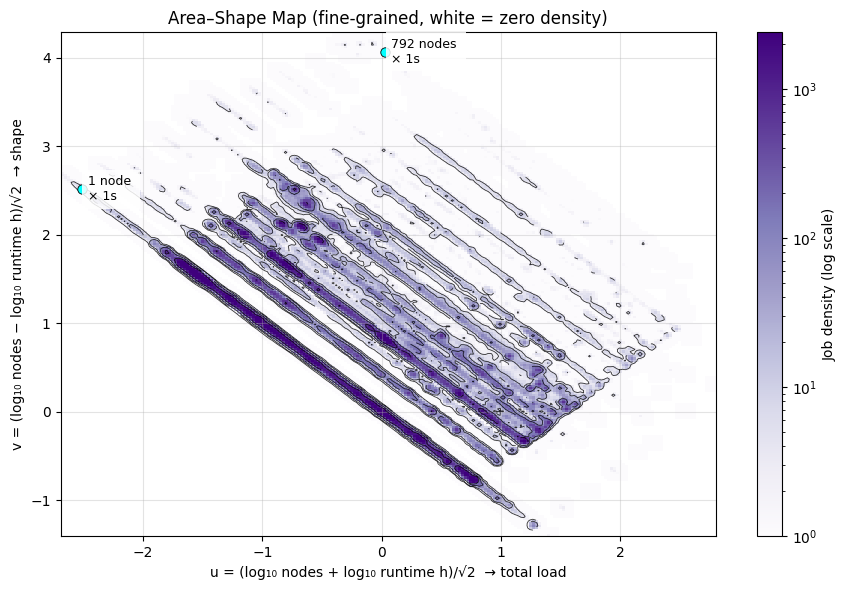

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# --- data prep (assumes alloc_df exists with num_nodes, runtime_hours) ---
valid = (alloc_df["num_nodes"] > 0) & (alloc_df["runtime_hours"] > 0)
df = alloc_df.loc[valid, ["num_nodes", "runtime_hours"]].copy()
ln_n = np.log10(df["num_nodes"].to_numpy())
ln_t = np.log10(df["runtime_hours"].to_numpy())

# area-shape transform
inv_sqrt2 = 1.0 / np.sqrt(2.0)
u = (ln_n + ln_t) * inv_sqrt2
v = (ln_n - ln_t) * inv_sqrt2

# --- fine-grained grid + gentle smoothing ---
xbins, ybins = 220, 220           # finer grid (tune as desired)
xmin, xmax = u.min(), u.max()
ymin, ymax = v.min(), v.max()
xedges = np.linspace(xmin, xmax, xbins + 1)
yedges = np.linspace(ymin, ymax, ybins + 1)

H, _, _ = np.histogram2d(u, v, bins=[xedges, yedges])
H = H.T  # rows=y, cols=x

# light smoothing: preserves detail but helps contours
sigma = 0.7
H_smooth = gaussian_filter(H, sigma=sigma, mode="nearest")

# mask zeros -> white; log scale for dynamic range
H_masked = np.ma.masked_where(H_smooth <= 0, H_smooth)

# make a copy of the colormap so global state isn't changed
cmap = plt.cm.Purples.copy()
cmap.set_bad(color="white")

# robust upper cap so a few super-hot bins don't wash out the rest
vmax = np.percentile(H_smooth[H_smooth > 0], 99.5) if np.any(H_smooth > 0) else 1.0
norm = mcolors.LogNorm(vmin=1, vmax=vmax)

# centers for contours
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcenters, ycenters, indexing="xy")

# --- example points to overlay (nodes, hours) ---
examples = [
    ("1 node \n× 1s", 1, (1/60)/60),
    ("792 nodes \n× 1s", 792, (5/60)/60),

]
def to_uv(nodes, hours):
    ln_n = np.log10(nodes); ln_t = np.log10(hours)
    return (ln_n + ln_t) * inv_sqrt2, (ln_n - ln_t) * inv_sqrt2

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    H_masked, origin="lower", extent=(xmin, xmax, ymin, ymax),
    aspect="auto", cmap=cmap, norm=norm, interpolation="nearest"
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("Job density (log scale)")

# contours over the same field (use normalized levels for a consistent look)
# choose a few levels so lines are visible but not cluttered
levels = mcolors.LogNorm(vmin=1, vmax=vmax).inverse([0.15, 0.35, 0.6, 0.85])
CS = ax.contour(X, Y, H_smooth, levels=levels, colors="k", linewidths=0.6, alpha=0.8)
ax.clabel(CS, inline=True, fontsize=8, fmt=" ")

# overlay example markers
for label, nodes, hrs in examples:
    ux, vy = to_uv(nodes, hrs)
    ax.scatter(ux, vy, s=46, c="cyan", edgecolors="black", linewidths=0.6, zorder=3)
    ax.text(ux + 0.05, vy, label, fontsize=9, va="center", ha="left",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

ax.set_xlabel("u = (log₁₀ nodes + log₁₀ runtime h)/√2  → total load")
ax.set_ylabel("v = (log₁₀ nodes − log₁₀ runtime h)/√2  → shape")
ax.set_title("Area–Shape Map (fine-grained, white = zero density)")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


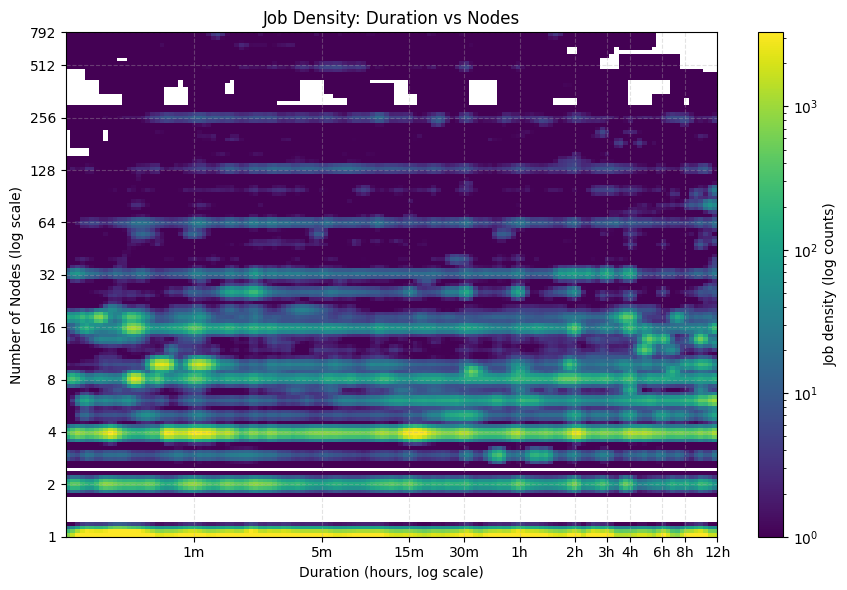

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
import pandas as pd

def plot_nodes_vs_duration_density(
    alloc_df,
    nodes_col="num_nodes",
    duration_col="runtime_hours",
    max_hours=12,
    x_tick_candidates=( # nice hours
        1/60, 5/60, 15/60, 0.5, 1, 2, 3, 4, 6, 8, 12
    ),
    y_tick_mode="pow2",   # "pow2" or "linear"
    bins_xy=(140, 140),
    smooth_sigma=0.8,
    cmap="viridis",
    figsize=(9, 6)
):
    """
    Plot job density with duration (hours) on x (log) and node count on y (log).

    - Only shows gridlines at manually selected ticks.
    - X ticks are filtered from x_tick_candidates up to max_hours.
    - Y ticks are powers of 2 (plus max if needed) or linear 1..max depending on y_tick_mode.

    Returns (fig, ax).
    """
    # --- validate / prep ---
    df = alloc_df[[nodes_col, duration_col]].copy()
    df = df.dropna()
    df = df[(df[nodes_col] > 0) & (df[duration_col] > 0)]
    if df.empty:
        raise ValueError("No positive values for nodes/duration after filtering.")

    # Cap to max_hours on the x-axis (but keep data for density)
    x_max = min(max_hours, df[duration_col].max())

    # Robust lower bound for x to avoid zeros
    x_min = max(df[duration_col].quantile(0.01), 1e-6)
    if x_min >= x_max:
        x_min = df[duration_col].min() * 0.9

    # Y range
    y_min = max(df[nodes_col].min(), 1)
    y_max = df[nodes_col].max()

    # --- bins (log-spaced) ---
    xbins, ybins = bins_xy
    xedges = np.logspace(np.log10(x_min), np.log10(x_max), xbins)
    yedges = np.logspace(np.log10(y_min), np.log10(y_max), ybins)

    # 2D histogram in original (x=hours, y=nodes) space
    H, _, _ = np.histogram2d(df[duration_col], df[nodes_col], bins=[xedges, yedges])

    # Smoothing + masking zeros
    Hs = gaussian_filter(H, sigma=smooth_sigma, mode="nearest")
    Hm = np.ma.masked_where(Hs <= 0, Hs)

    # Color normalization (log counts)
    vmax = np.percentile(Hs[Hs > 0], 99.5) if np.any(Hs > 0) else 1.0
    norm = mcolors.LogNorm(vmin=1, vmax=vmax)

    # --- figure ---
    fig, ax = plt.subplots(figsize=figsize)
    pcm = ax.pcolormesh(xedges, yedges, Hm.T, norm=norm, cmap=cmap, shading="auto")
    cb = fig.colorbar(pcm, ax=ax)
    cb.set_label("Job density (log counts)")

    # Axes scales
    ax.set_xscale("log")
    ax.set_yscale("log")

    # --- ticks: X (nice hours up to max_hours), Y (powers of 2 or linear) ---
    # X ticks
    x_ticks = [t for t in x_tick_candidates if (t >= x_min and t <= x_max)]
    if not x_ticks:
        # fallback: include min and max
        x_ticks = [x_min, x_max]
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))
    ax.xaxis.set_major_formatter(FixedFormatter(
        [("{:.0f}h".format(t) if t >= 1 else f"{int(round(t*60))}m") for t in x_ticks]
    ))

    # Y ticks
    if y_tick_mode == "pow2":
        # powers of two up to y_max
        pow2 = []
        v = 1
        while v <= y_max:
            if v >= y_min:
                pow2.append(v)
            v *= 2
        if pow2 and pow2[-1] != y_max:
            # include exact max if it's not a power of two and reasonably distinct
            if y_max / pow2[-1] > 1.05:
                pow2.append(int(y_max))
        y_ticks = pow2 if pow2 else [int(y_max)]
    else:
        y_ticks = list(range(int(y_min), int(y_max) + 1))

    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(FixedFormatter([str(int(t)) for t in y_ticks]))

    # --- gridlines only at our manual ticks ---
    # Turn off any existing minor grid; enable only major with our fixed locators
    ax.grid(False)
    ax.minorticks_off()
    ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.35)

    # Labels / limits / title
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Duration (hours, log scale)")
    ax.set_ylabel("Number of Nodes (log scale)")
    ax.set_title("Job Density: Duration vs Nodes")

    plt.tight_layout()
    return fig, ax

# --- Example call ---
fig, ax = plot_nodes_vs_duration_density(alloc_df, max_hours=12)
